<a href="https://colab.research.google.com/github/diegofuentes51/LAB07-CLASS/blob/develop/lab07c_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SEMANA 7: REGRESIÓN LOGÍSTICA. MÁQUINAS DE VECTOR DE SOPORTE

NOMBRES : DIEGO ALONSO FUENTES ARELLANO

In [1]:
#Primero se hace lo que es la importacion de las librerias que se va usar
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Luego en esta parte se carga la base de datos del cancer
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
column_names = ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
                'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
                'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
                'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
                'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
                'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
                'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst',
                'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

data = pd.read_csv(url, header=None, names=column_names)

# Aqui se convierte el diagnóstico a binario
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Aqui se eilimina la columna ID que no es relevante
data.drop('id', axis=1, inplace=True)

# Luego se muestra la información básica  con el pint ya que tenemos definido lo que es la info y la cabeza
print(data.info())
print(data.head())
# en el resulado  se puede ver el tipo de variable co el cual se esta trabajando y las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

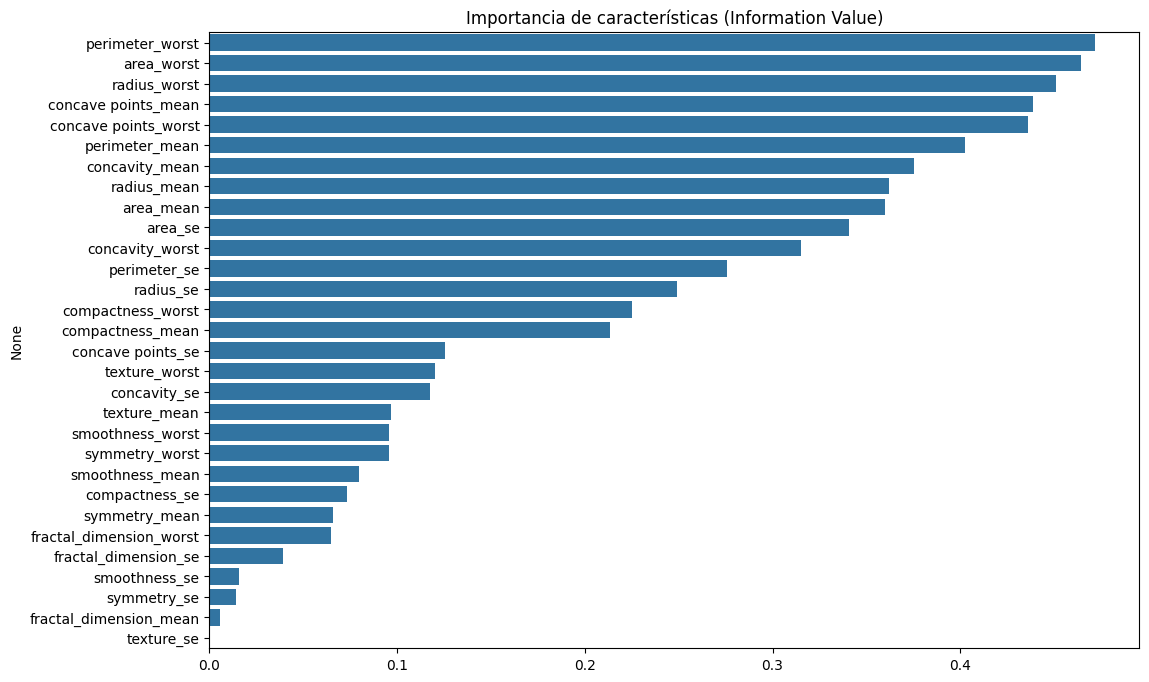

Características seleccionadas: ['perimeter_worst', 'area_worst', 'radius_worst', 'concave points_mean', 'concave points_worst', 'perimeter_mean', 'concavity_mean', 'radius_mean', 'area_mean', 'area_se', 'concavity_worst', 'perimeter_se', 'radius_se', 'compactness_worst', 'compactness_mean', 'concave points_se', 'texture_worst', 'concavity_se']


In [3]:
# Aqui luego lo separo las caracteristicas
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# Calculo la importancia de características usando información mutua
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# Visualizar los score
plt.figure(figsize=(12, 8))
sns.barplot(x=mi_scores.values, y=mi_scores.index)
plt.title('Importancia de características (Information Value)')
plt.show()

# Seleccionar características con MI > umbral
umbral = 0.1
selected_features = mi_scores[mi_scores > umbral].index
print(f"Características seleccionadas: {list(selected_features)}")

# Filtro los datos con características seleccionadas
X_selected = X[selected_features]

In [5]:
# Divido datos
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42, stratify=y)

# Luego los Estandarizo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Creo un modelo
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# luego se predice y se evalua
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_log))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_log):.4f}")

# Coeficientes del modelo
coef_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print("\nCoeficientes del modelo:")
print(coef_df)

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        90
           1       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

Matriz de confusión:
[[89  1]
 [ 3 50]]
Accuracy: 0.9720
AUC-ROC: 0.9981

Coeficientes del modelo:
                 Feature  Coefficient
16         texture_worst     1.503621
4   concave points_worst     1.480920
3    concave points_mean     1.256339
12             radius_se     1.144775
10       concavity_worst     1.132060
2           radius_worst     1.079961
1             area_worst     1.042914
0        perimeter_worst     0.802318
9                area_se     0.763135
6         concavity_mean     0.607278
11          perimeter_se     0.389868
8              area_mean     0.210054
15     concave points_se     0.156402
7            r

In [7]:
# Crear mmodelo usando kernel
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# se pedrice tambien y se evalua
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("\n=== Máquina de Vectores de Soporte ===")
print(classification_report(y_test, y_pred_svm))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_svm))
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_svm):.4f}")


=== Máquina de Vectores de Soporte ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        90
           1       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

Matriz de confusión:
[[89  1]
 [ 4 49]]
Accuracy: 0.9650
AUC-ROC: 0.9960



=== Comparación de Modelos ===
Regresión Logística - Accuracy: 0.9720, AUC-ROC: 0.9981
SVM - Accuracy: 0.9650, AUC-ROC: 0.9960


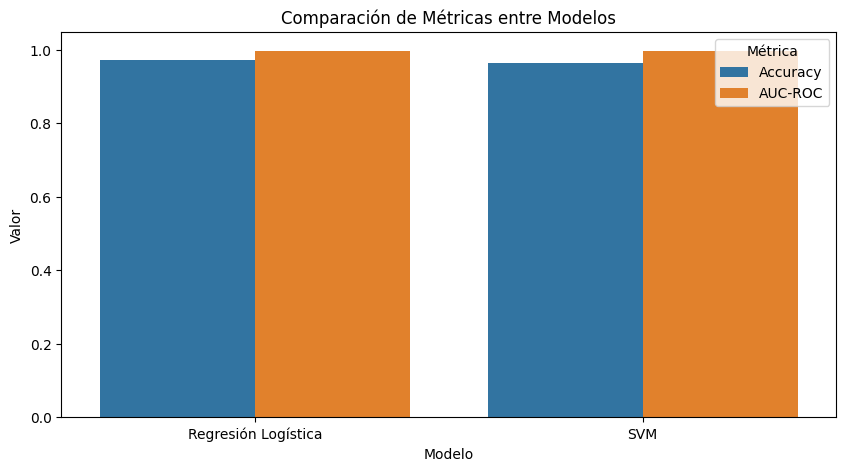

In [8]:
# Comparo las metricas
print("\n=== Comparación de Modelos ===")
print(f"Regresión Logística - Accuracy: {accuracy_score(y_test, y_pred_log):.4f}, AUC-ROC: {roc_auc_score(y_test, y_prob_log):.4f}")
print(f"SVM - Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}, AUC-ROC: {roc_auc_score(y_test, y_prob_svm):.4f}")

# Para ver las vizualizacion se usa ya el plot
metrics_df = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_svm)],
    'AUC-ROC': [roc_auc_score(y_test, y_prob_log), roc_auc_score(y_test, y_prob_svm)]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df.melt(id_vars='Modelo'), x='Modelo', y='value', hue='variable')
plt.title('Comparación de Métricas entre Modelos')
plt.ylabel('Valor')
plt.legend(title='Métrica')
plt.show()

En este trabajo lo que hice fue aplicar modelos de Regresión Logística y Máquinas de Vectores de Soporte para predecir si un tumor es maligno o benigno usando datos del cáncer de mama. Primero filtré las características más importantes con mutual information y luego entrené ambos modelos usando esas variables. Los resultados fueron bastante buenos, ya que ambos modelos tuvieron una precisión de alrededor del 97%, pero lo que más me llamó la atención fue el valor del AUC-ROC en la regresión logística (0.9981), lo cual indica que el modelo distingue muy bien entre casos positivos y negativos. Además, viendo los coeficientes pude identificar qué características influyen más en la predicción. En resumen, el análisis funcionó bien y me ayudó a entender mejor cómo estos modelos clasifican datos reales.